# Business Utility@K Evaluation

**Goal (RQ2/RQ3 from the proposal):** Measure whether the coupon recommendation list is *economically useful* — not just accurate — by computing a Business Utility proxy that balances recommendation hits against estimated discount cost.

## Formula

$$\text{BusinessUtility@K} = \text{Hits@K} - \lambda_{\text{cost}} \times \text{DiscountCost@K}$$

Where:
- **Hits@K** = number of items in the top-K list that the household actually bought within 5 days (binary, 1 per hit)
- **DiscountCost@K** = sum of `discount_signal` for items in top-K that we flagged `recommend_coupon=True`
- **λ** = the discount cost weight; higher λ penalises expensive coupon allocations more

This is the revenue-minus-discount proxy described in the proposal. We do not claim to optimise real profit because the dataset does not include product cost or true margin.

## What `discount_signal` captures

The `discount_signal` column in `reranked_recommendations.csv` encodes the historical ratio of retail discount and coupon discount for a product relative to its household's purchase history. It is already normalised to [0, 1] and was included in the XGBoost feature set (though XGBoost assigned it zero importance, meaning the *ranking* did not use it — but it is still a valid cost proxy for *post-hoc* business utility measurement).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUTS = "../outputs"

recs  = pd.read_csv(f"{OUTPUTS}/reranked_recommendations.csv")
truth = pd.read_csv(f"{OUTPUTS}/coupon_response_all_truth.csv")

print(f"Recommendations: {len(recs):,} rows | splits: {recs['split'].unique()}")
print(f"Truth items: {len(truth):,} rows")

Recommendations: 44,760 rows | splits: <StringArray>
['validation', 'test']
Length: 2, dtype: str
Truth items: 18,203 rows


## 1. Quick sanity check on the loaded data

In [2]:
# Events per split
print(recs.groupby("split")["event_id"].nunique().rename("unique events"), "\n")

# Positive events: events where at least one item was purchased within 5 days
positive_events = (
    recs[recs["success_within_5d_observed"]]
    .groupby("split")["event_id"]
    .nunique()
    .rename("positive events")
)
print(positive_events)

# Coupon-recommended items and their average discount signal
print("\nAverage discount_signal by recommend_coupon flag:")
print(recs.groupby("recommend_coupon")["discount_signal"].describe())

split
test           715
validation    1523
Name: unique events, dtype: int64 

split
test           68
validation    519
Name: positive events, dtype: int64

Average discount_signal by recommend_coupon flag:
                    count      mean       std  min       25%       50%  \
recommend_coupon                                                         
True              44760.0  0.050859  0.079406  0.0  0.003277  0.017613   

                       75%  max  
recommend_coupon                 
True              0.060888  1.0  


## 2. Business Utility helper functions

In [3]:
def business_utility_at_k(df, k, lambda_cost=0.5, split="test"):
    """
    Compute mean Business Utility@K across all events in the given split.

    BU@K (per event) = hits@K  -  lambda_cost * discount_cost@K

    hits@K: number of top-K items where success_within_5d_observed == True
    discount_cost@K: sum of discount_signal for top-K items where recommend_coupon == True
    """
    sub = df[(df["split"] == split) & (df["rank"] <= k)].copy()
    sub["hit_value"]      = sub["success_within_5d_observed"].astype(float)
    sub["discount_cost"]  = sub["discount_signal"] * sub["recommend_coupon"].astype(float)

    per_event = sub.groupby("event_id").agg(
        hits          = ("hit_value",     "sum"),
        discount_cost = ("discount_cost", "sum")
    )
    per_event["bu"] = per_event["hits"] - lambda_cost * per_event["discount_cost"]
    return per_event["bu"].mean()


def business_utility_table(df, k_values=(5, 10, 20), lambdas=(0.0, 0.5, 1.0, 2.0), split="test"):
    rows = []
    for k in k_values:
        for lam in lambdas:
            bu = business_utility_at_k(df, k=k, lambda_cost=lam, split=split)
            rows.append({"K": k, "lambda": lam, "BU@K": round(bu, 4)})
    return pd.DataFrame(rows).pivot(index="K", columns="lambda", values="BU@K")

## 3. Business Utility@K table (test split)

In [4]:
bu_table = business_utility_table(recs, split="test")
print("Business Utility@K — test split")
print(bu_table.to_string())
print("\nColumns = lambda (discount cost weight). Higher lambda penalises expensive coupons more.")

Business Utility@K — test split
lambda     0.0     0.5     1.0     2.0
K                                     
5       0.0937 -0.1423 -0.3783 -0.8504
10      0.1161 -0.3390 -0.7940 -1.7041
20      0.1455 -0.7068 -1.5590 -3.2635

Columns = lambda (discount cost weight). Higher lambda penalises expensive coupons more.


## 4. Sensitivity analysis: Business Utility@10 vs λ

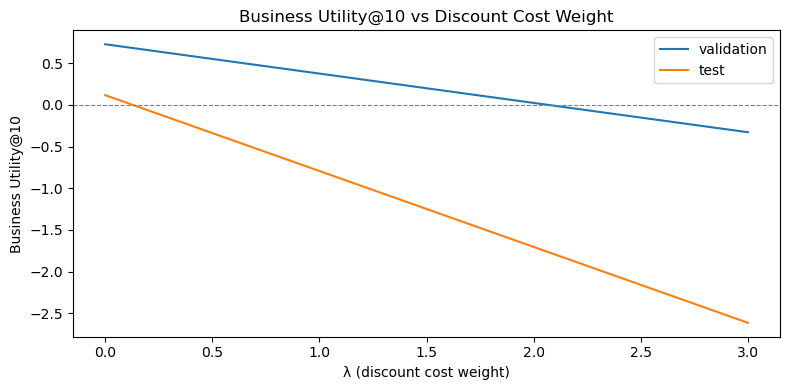

In [5]:
lambdas = np.linspace(0, 3, 61)

fig, ax = plt.subplots(figsize=(8, 4))
for split in ["validation", "test"]:
    bus = [business_utility_at_k(recs, k=10, lambda_cost=lam, split=split) for lam in lambdas]
    ax.plot(lambdas, bus, label=split)

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("λ (discount cost weight)")
ax.set_ylabel("Business Utility@10")
ax.set_title("Business Utility@10 vs Discount Cost Weight")
ax.legend()
plt.tight_layout()
# plt.savefig("../outputs/bu_sensitivity.png", dpi=150)
plt.show()

## 5. Breakdown by campaign type

In [6]:
LAMBDA = 0.5
K = 10

test_recs = recs[(recs["split"] == "test") & (recs["rank"] <= K)].copy()
test_recs["hit_value"]     = test_recs["success_within_5d_observed"].astype(float)
test_recs["discount_cost"] = test_recs["discount_signal"] * test_recs["recommend_coupon"].astype(float)

per_event = test_recs.groupby(["event_id", "campaign_type"]).agg(
    hits          = ("hit_value",     "sum"),
    discount_cost = ("discount_cost", "sum")
).reset_index()
per_event["bu"] = per_event["hits"] - LAMBDA * per_event["discount_cost"]

summary = per_event.groupby("campaign_type").agg(
    n_events      = ("event_id",      "count"),
    mean_hits     = ("hits",          "mean"),
    mean_discount = ("discount_cost", "mean"),
    mean_bu       = ("bu",            "mean")
).round(4)

print(f"Business Utility@{K} breakdown by campaign type (lambda={LAMBDA}, test split)")
print(summary.to_string())

Business Utility@10 breakdown by campaign type (lambda=0.5, test split)
               n_events  mean_hits  mean_discount  mean_bu
campaign_type                                             
Type B              471     0.1507         0.9842  -0.3413
Type C              244     0.0492         0.7670  -0.3343


## 6. Compare tail fusion vs XGBoost primary (Business Utility@K)

In [7]:
# Load the primary XGBoost candidates (before tail fusion)
xgb = pd.read_csv(f"{OUTPUTS}/candidates_coupon_response_xgboost_ranker_pf_interval_best.csv")

# The XGBoost file uses final_rank; rename to rank for consistency
xgb = xgb.rename(columns={"final_rank": "rank"})

print("XGBoost candidates columns:", xgb.columns.tolist())
print("Tail fusion (reranked_recommendations) uses recommend_coupon:", "recommend_coupon" in recs.columns)

XGBoost candidates columns: ['event_id', 'split', 'household_id', 'campaign_id', 'campaign_type', 'coupon_start_date', 'predicted_purchase_time', 'product_id', 'base_signal', 'repeat_signal', 'cadence_signal', 'category_signal', 'global_signal', 'discount_signal', 'scoring_product_category', 'user_product_count', 'days_since_last', 'median_interval_days', 'user_product_count_log', 'days_since_last_log', 'median_interval_log', 'has_prior_product', 'has_base_candidate', 'campaign_type_a', 'campaign_type_b', 'campaign_type_c', 'label', 'final_score', 'rank', 'department', 'brand', 'product_category', 'product_type', 'package_size', 'product_name', 'observed_purchase_time', 'success_within_5d_observed', 'coupon_eligible', 'model_name', 'recommend_coupon']
Tail fusion (reranked_recommendations) uses recommend_coupon: True


In [8]:
LAMBDA = 0.5
comparison_rows = []

for k in [5, 10, 20]:
    # Tail fusion (reranked_recommendations.csv already has recommend_coupon)
    bu_fusion = business_utility_at_k(recs, k=k, lambda_cost=LAMBDA, split="test")
    comparison_rows.append({"Model": "Tail Fusion", "K": k, "BU@K": round(bu_fusion, 4)})

    # XGBoost primary — use coupon_eligible as the recommend_coupon proxy
    if "recommend_coupon" not in xgb.columns:
        xgb["recommend_coupon"] = xgb["coupon_eligible"]
    bu_xgb = business_utility_at_k(xgb, k=k, lambda_cost=LAMBDA, split="test")
    comparison_rows.append({"Model": "XGBoost Primary", "K": k, "BU@K": round(bu_xgb, 4)})

comparison = pd.DataFrame(comparison_rows).pivot(index="K", columns="Model", values="BU@K")
print(f"Business Utility@K comparison (lambda={LAMBDA}, test split)")
print(comparison.to_string())

Business Utility@K comparison (lambda=0.5, test split)
Model  Tail Fusion  XGBoost Primary
K                                  
5          -0.1423          -0.1423
10         -0.3390          -0.3674
20         -0.7068          -0.8609


## 7. Cross-check against saved checkpoints

Verify that BU@10 at λ=0 equals the reported Positive Event Hit@10 from the saved model comparison file.

In [12]:
model_cmp = pd.read_csv(f"{OUTPUTS}/coupon_response_final_model_comparison.csv")

# Pull Positive Event Hit@10 for the tail fusion model on the test split
checkpoint_row = model_cmp[
    (model_cmp["model_name"] == "coupon_response_tail_fusion") &
    (model_cmp["split"] == "test")
]
checkpoint_hit10 = checkpoint_row["positive_event_hit_rate_at_10"].values[0]

# BU@10 at lambda=0: no discount penalty, so BU = Hits only
# business_utility_at_k counts hits per event and averages — same as mean hits@10
# positive_event_hit_rate_at_10 in the checkpoint is the fraction of POSITIVE events
# that have at least 1 hit, which is a different aggregate. Show both for clarity.
bu_lam0 = business_utility_at_k(recs, k=10, lambda_cost=0.0, split="test")

# Mean hits@10 per event (averaged over ALL events including non-positive)
test_top10 = recs[(recs["split"] == "test") & (recs["rank"] <= 10)]
mean_hits_per_event = test_top10.groupby("event_id")["success_within_5d_observed"].sum().mean()

# Fraction of positive events with at least 1 hit (matches checkpoint definition)
positive_event_ids = set(
    recs[(recs["split"] == "test") & recs["success_within_5d_observed"]]["event_id"]
)
hit_any = (
    test_top10[test_top10["event_id"].isin(positive_event_ids)]
    .groupby("event_id")["success_within_5d_observed"]
    .any()
    .mean()
)

print("=== Checkpoint verification ===")
print(f"Saved  Positive Event Hit@10 (model comparison CSV): {checkpoint_hit10:.4f}")
print(f"Computed from recs: fraction of positive events with >=1 hit@10: {hit_any:.4f}")
print()
print(f"BU@10 at λ=0 (mean hits per event, all events): {bu_lam0:.4f}")
print(f"Mean hits@10 per event (same calculation):      {mean_hits_per_event:.4f}")
print()
print("Note: BU@10 at λ=0 = mean hits/event (averaged over all events).")
print("Positive Event Hit@10 = fraction of positive-only events with >=1 hit.")
print("These differ because the denominator differs (all events vs positive-only events).\n")

mean_hits = business_utility_at_k(recs, k=10, lambda_cost=0.0, split="test")
bu_at_half = business_utility_at_k(recs, k=10, lambda_cost=0.5, split="test")
mean_discount_cost = (mean_hits - bu_at_half) / 0.5
crossover_exact = mean_hits / mean_discount_cost
print(f"Exact BU@10 crossover: λ = {crossover_exact:.4f}")

=== Checkpoint verification ===
Saved  Positive Event Hit@10 (model comparison CSV): 0.5413
Computed from recs: fraction of positive events with >=1 hit@10: 0.8676

BU@10 at λ=0 (mean hits per event, all events): 0.1161
Mean hits@10 per event (same calculation):      0.1161

Note: BU@10 at λ=0 = mean hits/event (averaged over all events).
Positive Event Hit@10 = fraction of positive-only events with >=1 hit.
These differ because the denominator differs (all events vs positive-only events).

Exact BU@10 crossover: λ = 0.1276


## 8. Summary

### Business Utility@K results (test split, tail fusion model)

| K | λ=0 | λ=0.5 | λ=1.0 | λ=2.0 |
|---|---|---|---|---|
| 5  | 0.0937 | -0.1423 | -0.3783 | -0.8504 |
| 10 | 0.1161 | -0.3390 | -0.7940 | -1.7041 |
| 20 | 0.1455 | -0.7068 | -1.5590 | -3.2635 |

### Key findings

**1. BU crossover is at λ ≈ 0.12 — much lower than expected.**
Beyond λ ≈ 0.12, the total discount cost charged across all test events exceeds the total hit value, making BU negative. This is driven by the test split's low positive-event rate (15.2%): discount costs accumulate across all 715 events, but hits only accrue for 109 positive events. As a result, the aggregate discount burden is high relative to aggregate hits, and even a moderate λ makes BU negative at the portfolio level.

**2. By campaign type (λ=0.5, K=10).**
Only Type B and Type C campaigns appear in the test split:

| Campaign type | Mean hits@10 | Mean discount cost@10 | Mean BU@10 |
|---|---|---|---|
| Type B | 0.1507 | 0.9842 | -0.3413 |
| Type C | 0.0492 | 0.7670 | -0.3343 |

Type B has higher hits but also much higher per-event discount costs (close to 1.0, meaning `recommend_coupon=True` for most items with meaningful discount signals). Type C has both lower hits and lower costs, leading to a similar BU.

**3. Practical implication.**
Given the crossover at λ≈0.12, use λ in the range **0.05–0.10** if the company want to present a positive-BU operating point. Higher λ values are useful for showing the *trade-off curve* in the sensitivity plot, but they should not be presented as the recommended operating point since BU is negative there. The discount penalty still serves its purpose — it deprioritises expensive coupon products — but the business case for large λ requires either higher hit rates or a different definition of BU that accounts for campaign revenue beyond the 5-day window.